In [1]:
import torch
import torchvision
from torchvision import models

In [2]:
vgg = models.vgg16(weights = 'DEFAULT')
vgg.eval()
print("VGG loaded")

resnet = models.resnet50(weights = 'DEFAULT')
resnet.eval()
print("Resnet loaded")

googlenet = models.googlenet(weights = 'DEFAULT')
googlenet.eval()
print("Googlenet loaded")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 67.3MB/s]


VGG loaded
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 76.6MB/s]


Resnet loaded
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 85.2MB/s]


Googlenet loaded


In [5]:
vgg_params = sum(p.numel() for p in vgg.parameters())
resnet_params = sum(p.numel() for p in resnet.parameters())
googlenet_params = sum(p.numel() for p in googlenet.parameters())
print(f"VGG16 : {vgg_params}")
print(f"RESTNET50: {resnet_params}")
print(f"GOOGLENET : {googlenet_params}")

VGG16 : 138357544
RESTNET50: 25557032
GOOGLENET : 6624904


In [7]:
models_data = {
    vgg : vgg_params,
    resnet : resnet_params,
    googlenet : googlenet_params
}
for name,params in models_data.items():
  print(name, "->", params, "parameters")

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [8]:
print("VGG16 Layers:", len(list(vgg.children())))
print("ResNet50 Layers:", len(list(resnet.children())))
print("GoogLeNet Layers:", len(list(googlenet.children())))

VGG16 Layers: 3
ResNet50 Layers: 10
GoogLeNet Layers: 19


In [9]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["VGG16", "ResNet50", "GoogLeNet"],
        "Parameters": [vgg_params, resnet_params, googlenet_params]
        })

print(comparison)

       Model  Parameters
0      VGG16   138357544
1   ResNet50    25557032
2  GoogLeNet     6624904


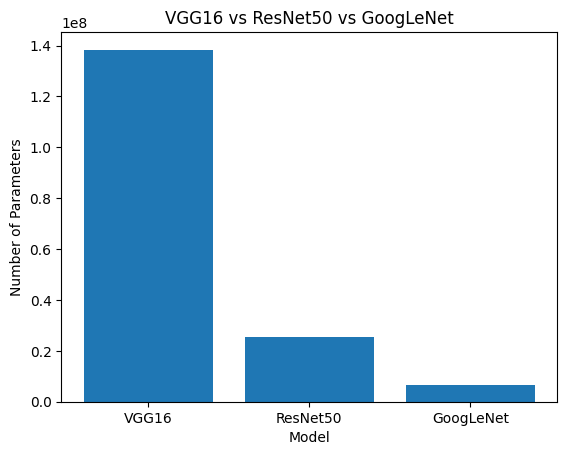

In [10]:
import matplotlib.pyplot as plt

plt.bar(comparison["Model"], comparison["Parameters"])
plt.xlabel("Model")
plt.ylabel("Number of Parameters")
plt.title("VGG16 vs ResNet50 vs GoogLeNet")
plt.show()

In [11]:
print("VGG16 has the largest number of parameters.")
print("ResNet50 uses residual connections.")
print("GoogLeNet uses Inception modules and fewer parameters.")

VGG16 has the largest number of parameters.
ResNet50 uses residual connections.
GoogLeNet uses Inception modules and fewer parameters.
